In [5]:
%pip install openpyxl

   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   ------ -------------------------------- 41.0/250.9 kB 330.3 kB/s eta 0:00:01
   --------------- ---------------------- 102.4/250.9 kB 658.3 kB/s eta 0:00:01
   -------------------------------- ------- 204.8/250.9 kB 1.0 MB/s eta 0:00:01
   ---------------------------------------  245.8/250.9 kB 1.1 MB/s eta 0:00:01
   -------------------------------------- 250.9/250.9 kB 856.5 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 325.1 kB/s eta 0:05:13
   ---------------------------------------- 0.1/101.7 MB 363.1 kB/s eta 0:04:40
   ---------------------------------------- 0.1/101.7 MB 595.3 kB/s eta 0:02:51
   ---------------------------------------- 0.2/101.7 MB 610.0 kB/s eta 0:02:47
   ---------------------------------------- 0.3/101.7 MB 947.5 kB/s eta 0:01:48
   ---------------------------------------- 0.5/101.7 MB 1.3 MB/s eta 0:01:16
   ---------------------------------------- 0.6/101.7 MB 1.6 MB/s eta 0:01:03
   ---------------------------------------- 0.9/101.7 MB 2.1 MB/s eta 0:00:49
   ---------------------------------------- 1.2/101.7 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 1.4/101.7 MB 2.7 MB/s eta 0:00:


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Anemia Prediction - Machine Learning Project

### Project Structure:
- **1**: Data Preprocessing & Cleaning
- **2**: Exploratory Data Analysis (EDA) & Visualization
- **3**: Feature Engineering
- **4**: Model Training with Cross-Validation & Hyperparameter Tuning
- **5**: Early Stopping, Model Evaluation & Deployment

---

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

# For early stopping
import xgboost as xgb

# For model persistence
import joblib
import pickle

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("All libraries imported successfully!")

All libraries imported successfully!


---
# DATA PREPROCESSING & CLEANING
---

In [2]:
# Load the dataset
df = pd.read_excel('SKILICARSLAN_Anemia_DataSet.xlsx')

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset loaded successfully!

Dataset Shape: (15300, 29)

Columns: ['GENDER', 'WBC', 'NE#', 'LY#', 'MO#', 'EO#', 'BA#', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDW', 'PLT', 'MPV', 'PCT', 'PDW', 'SD', 'SDTSD', 'TSD', 'FERRITTE', 'FOLATE', 'B12', 'All_Class', 'HGB_Anemia_Class', 'Iron_anemia_Class', 'Folate_anemia_class', 'B12_Anemia_class']


In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,GENDER,WBC,NE#,LY#,MO#,EO#,BA#,RBC,HGB,HCT,MCV,MCH,MCHC,RDW,PLT,MPV,PCT,PDW,SD,SDTSD,TSD,FERRITTE,FOLATE,B12,All_Class,HGB_Anemia_Class,Iron_anemia_Class,Folate_anemia_class,B12_Anemia_class
0,1,10.63,6.31,2.79,0.91,0.56,0.06,4.31,12.7,37.6,87.2,29.5,33.8,12.8,364.0,9.6,0.35,10.6,100.00,248.90,40.176778,194.00,5.06,178.2,4,0,0,0,1
1,1,5.08,2.50,1.87,0.43,0.26,0.02,4.34,12.8,36.9,85.0,29.5,34.7,12.1,205.0,9.8,0.20,10.8,116.68,348.48,33.482553,57.37,9.88,197.7,4,0,0,0,1
2,1,13.68,9.40,2.69,1.55,0.03,0.01,3.18,9.4,27.5,86.5,29.6,34.2,18.1,378.0,9.7,0.36,8.8,71.97,357.27,20.144429,114.20,8.37,143.0,4,0,0,0,1
3,1,5.60,3.94,0.83,0.54,0.26,0.03,3.35,10.5,31.4,93.7,31.3,33.4,12.2,177.0,10.1,0.18,10.8,100.00,360.60,27.731559,214.20,6.39,139.9,4,0,0,0,1
4,1,3.57,2.03,1.25,0.10,0.18,0.01,1.31,5.1,14.3,109.2,38.9,35.7,19.9,124.0,11.2,0.14,12.6,176.08,223.28,78.860623,303.40,4.30,50.0,4,0,0,0,1


In [4]:
# Check data types and basic information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 15300 entries, 0 to 15299
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GENDER               15300 non-null  int64  
 1   WBC                  15300 non-null  float64
 2   NE#                  15300 non-null  float64
 3   LY#                  15300 non-null  float64
 4   MO#                  15300 non-null  float64
 5   EO#                  15300 non-null  float64
 6   BA#                  15300 non-null  float64
 7   RBC                  15300 non-null  float64
 8   HGB                  15300 non-null  float64
 9   HCT                  15300 non-null  float64
 10  MCV                  15300 non-null  float64
 11  MCH                  15300 non-null  float64
 12  MCHC                 15300 non-null  float64
 13  RDW                  15300 non-null  float64
 14  PLT                  15300 non-null  float64
 15  MPV                  15300

In [5]:
# Check for missing values
print("Missing Values Count:")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Missing Values Count:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


In [6]:
# Handle missing values
# Strategy: For numerical features, use median; for categorical, use mode

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target variable from the list if it exists
target_candidates = ['All_Class', 'HGB_Anemia_Class', 'Iron_anemia_Class', 
                     'Folate_anemia_class', 'B12_Anemia_class', 
                     'Anemia', 'Result', 'Target', 'Label']

target_col = None
for col in target_candidates:
    if col in df.columns:
        target_col = col
        if col in numerical_cols:
            numerical_cols.remove(col)
        if col in categorical_cols:
            categorical_cols.remove(col)
        break

print(f"Target column identified: {target_col}")
print(f"\nNumerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Target column identified: All_Class

Numerical features: 28
Categorical features: 0


In [7]:
# Fill missing values in numerical columns with median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Filled {col} with median: {median_value}")

# Fill missing values in categorical columns with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Filled {col} with mode: {mode_value}")

print("\nMissing values after imputation:")
print(df.isnull().sum().sum())


Missing values after imputation:
0


In [8]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicates} duplicate rows")
    print(f"New dataset shape: {df.shape}")

Number of duplicate rows: 88
Removed 88 duplicate rows
New dataset shape: (15212, 29)


In [9]:
# Check for outliers using IQR method
def detect_outliers_iqr(data, columns):
    outliers_dict = {}
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outliers_dict[col] = len(outliers)
    
    return outliers_dict

outliers = detect_outliers_iqr(df, numerical_cols)
print("Outliers detected per column:")
for col, count in outliers.items():
    if count > 0:
        print(f"{col}: {count} outliers")

Outliers detected per column:
WBC: 626 outliers
NE#: 837 outliers
LY#: 327 outliers
MO#: 554 outliers
EO#: 752 outliers
BA#: 357 outliers
RBC: 531 outliers
HGB: 381 outliers
HCT: 372 outliers
MCV: 834 outliers
MCH: 840 outliers
MCHC: 433 outliers
RDW: 442 outliers
PLT: 541 outliers
MPV: 103 outliers
PCT: 437 outliers
SD: 301 outliers
SDTSD: 410 outliers
TSD: 403 outliers
FERRITTE: 1670 outliers
FOLATE: 697 outliers
B12: 1091 outliers
HGB_Anemia_Class: 1015 outliers
Folate_anemia_class: 152 outliers
B12_Anemia_class: 198 outliers


In [10]:
# Handle outliers - Cap them at 5th and 95th percentiles
for col in numerical_cols:
    if outliers[col] > 0:
        lower_limit = df[col].quantile(0.05)
        upper_limit = df[col].quantile(0.95)
        df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)
        print(f"Capped outliers in {col}")

print("\nOutlier handling completed!")

Capped outliers in WBC
Capped outliers in NE#
Capped outliers in LY#
Capped outliers in MO#
Capped outliers in EO#
Capped outliers in BA#
Capped outliers in RBC
Capped outliers in HGB
Capped outliers in HCT
Capped outliers in MCV
Capped outliers in MCH
Capped outliers in MCHC
Capped outliers in RDW
Capped outliers in PLT
Capped outliers in MPV
Capped outliers in PCT
Capped outliers in SD
Capped outliers in SDTSD
Capped outliers in TSD
Capped outliers in FERRITTE
Capped outliers in FOLATE
Capped outliers in B12
Capped outliers in HGB_Anemia_Class
Capped outliers in Folate_anemia_class
Capped outliers in B12_Anemia_class

Outlier handling completed!


In [11]:
# Save preprocessed data
df.to_csv('preprocessed_anemia_data.csv', index=False)
print("Preprocessed data saved as 'preprocessed_anemia_data.csv'")
print(f"\nFinal dataset shape: {df.shape}")

Preprocessed data saved as 'preprocessed_anemia_data.csv'

Final dataset shape: (15212, 29)


---
# EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION
---

In [12]:
# Load preprocessed data (if starting from here)
# df = pd.read_csv('preprocessed_anemia_data.csv')

print("Starting EDA...")
print(f"Dataset shape: {df.shape}")

Starting EDA...
Dataset shape: (15212, 29)


In [13]:
# Statistical summary
print("Statistical Summary of Numerical Features:")
df.describe().T

Statistical Summary of Numerical Features:


,count,mean,std,min,25%,50%,75%,max
GENDER,15212.0,0.320668,0.466749,0.000000,0.000000,0.000000,1.000000,1.000000
WBC,15212.0,7.854020,2.332516,4.410000,6.100000,7.480000,9.210000,13.174500
NE#,15212.0,4.868064,2.009262,2.240000,3.390000,4.410000,5.870000,9.880000
LY#,15212.0,2.154742,0.712102,0.930000,1.640000,2.120000,2.640000,3.570000
MO#,15212.0,0.557130,0.189046,0.280000,0.411950,0.530000,0.670000,0.980000
EO#,15212.0,0.143494,0.107690,0.010000,0.060000,0.120000,0.200000,0.410000
BA#,15212.0,0.058788,0.029515,0.012550,0.040000,0.054000,0.080000,0.120000
RBC,15212.0,4.695952,0.563256,3.600000,4.320000,4.700000,5.080000,5.750000
HGB,15212.0,12.790075,1.867424,9.100000,11.600000,12.820000,14.100000,16.124500
HCT,15212.0,38.985743,4.910684,29.300000,35.700000,39.130000,42.472500,47.750000



Target Variable (All_Class) Distribution:
All_Class
0    9672
2    4175
1    1015
4     198
3     152
Name: count, dtype: int64

Class Balance:
All_Class
0    63.581383
2    27.445438
1     6.672364
4     1.301604
3     0.999211
Name: proportion, dtype: float64


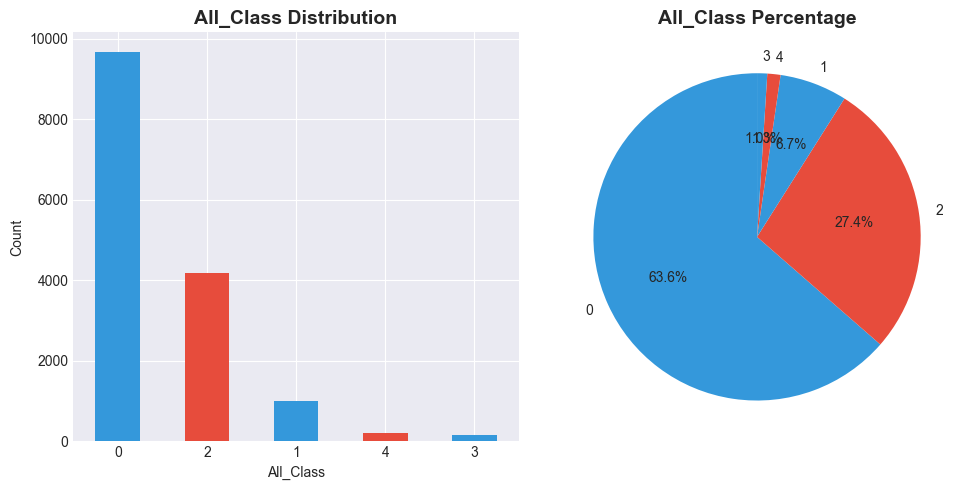


Target distribution plot saved as 'target_distribution.png'


In [14]:
# Target variable distribution
if target_col:
    print(f"\nTarget Variable ({target_col}) Distribution:")
    print(df[target_col].value_counts())
    print(f"\nClass Balance:")
    print(df[target_col].value_counts(normalize=True) * 100)
    
    # Visualize target distribution
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    df[target_col].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
    plt.title(f'{target_col} Distribution', fontsize=14, fontweight='bold')
    plt.xlabel(target_col)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    
    plt.subplot(1, 2, 2)
    df[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                       colors=['#3498db', '#e74c3c'],
                                       startangle=90)
    plt.title(f'{target_col} Percentage', fontsize=14, fontweight='bold')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nTarget distribution plot saved as 'target_distribution.png'")

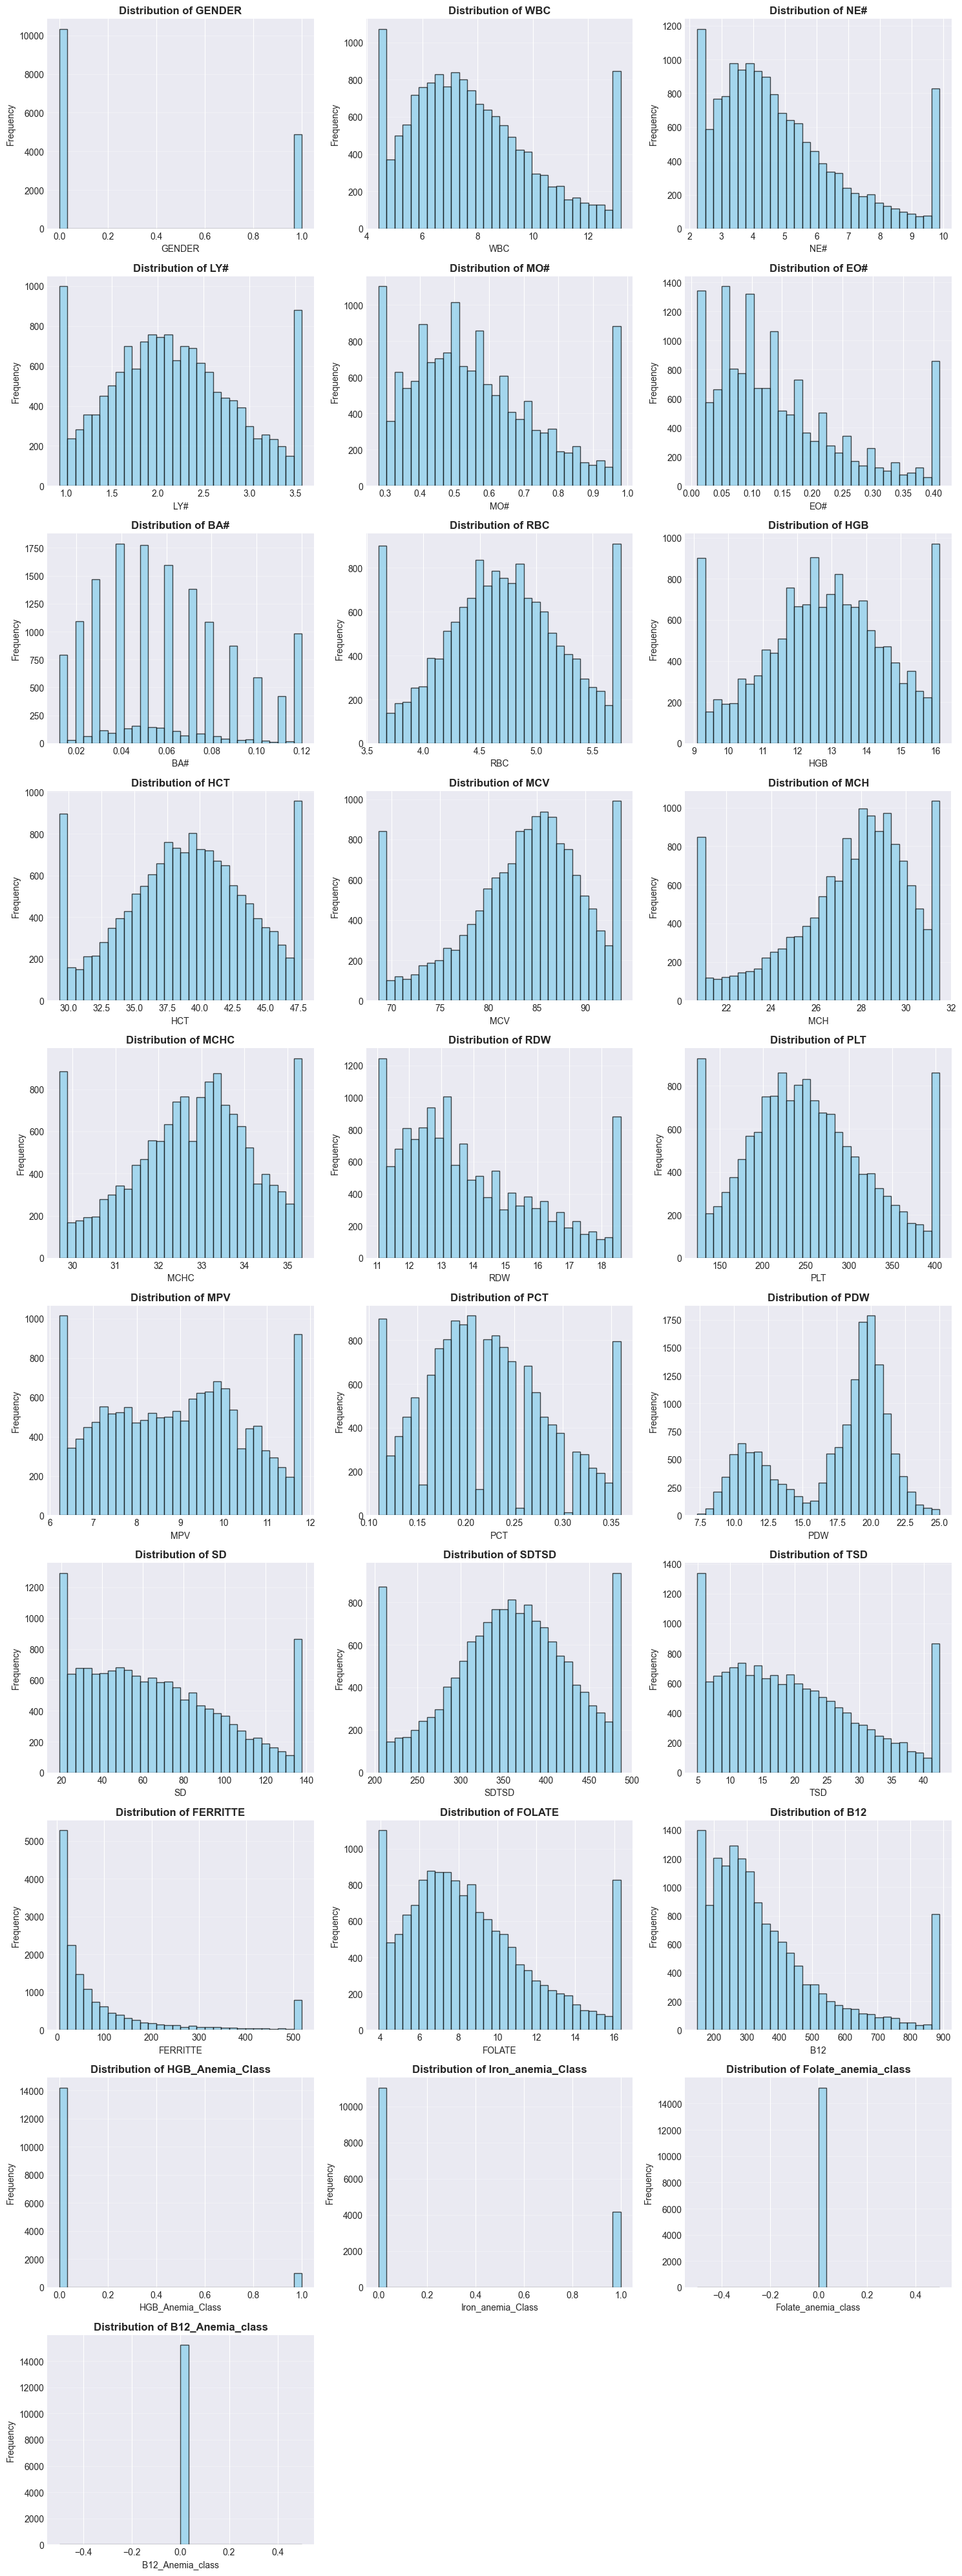

Numerical distributions plot saved as 'numerical_distributions.png'


In [15]:
# Distribution of numerical features
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Numerical distributions plot saved as 'numerical_distributions.png'")

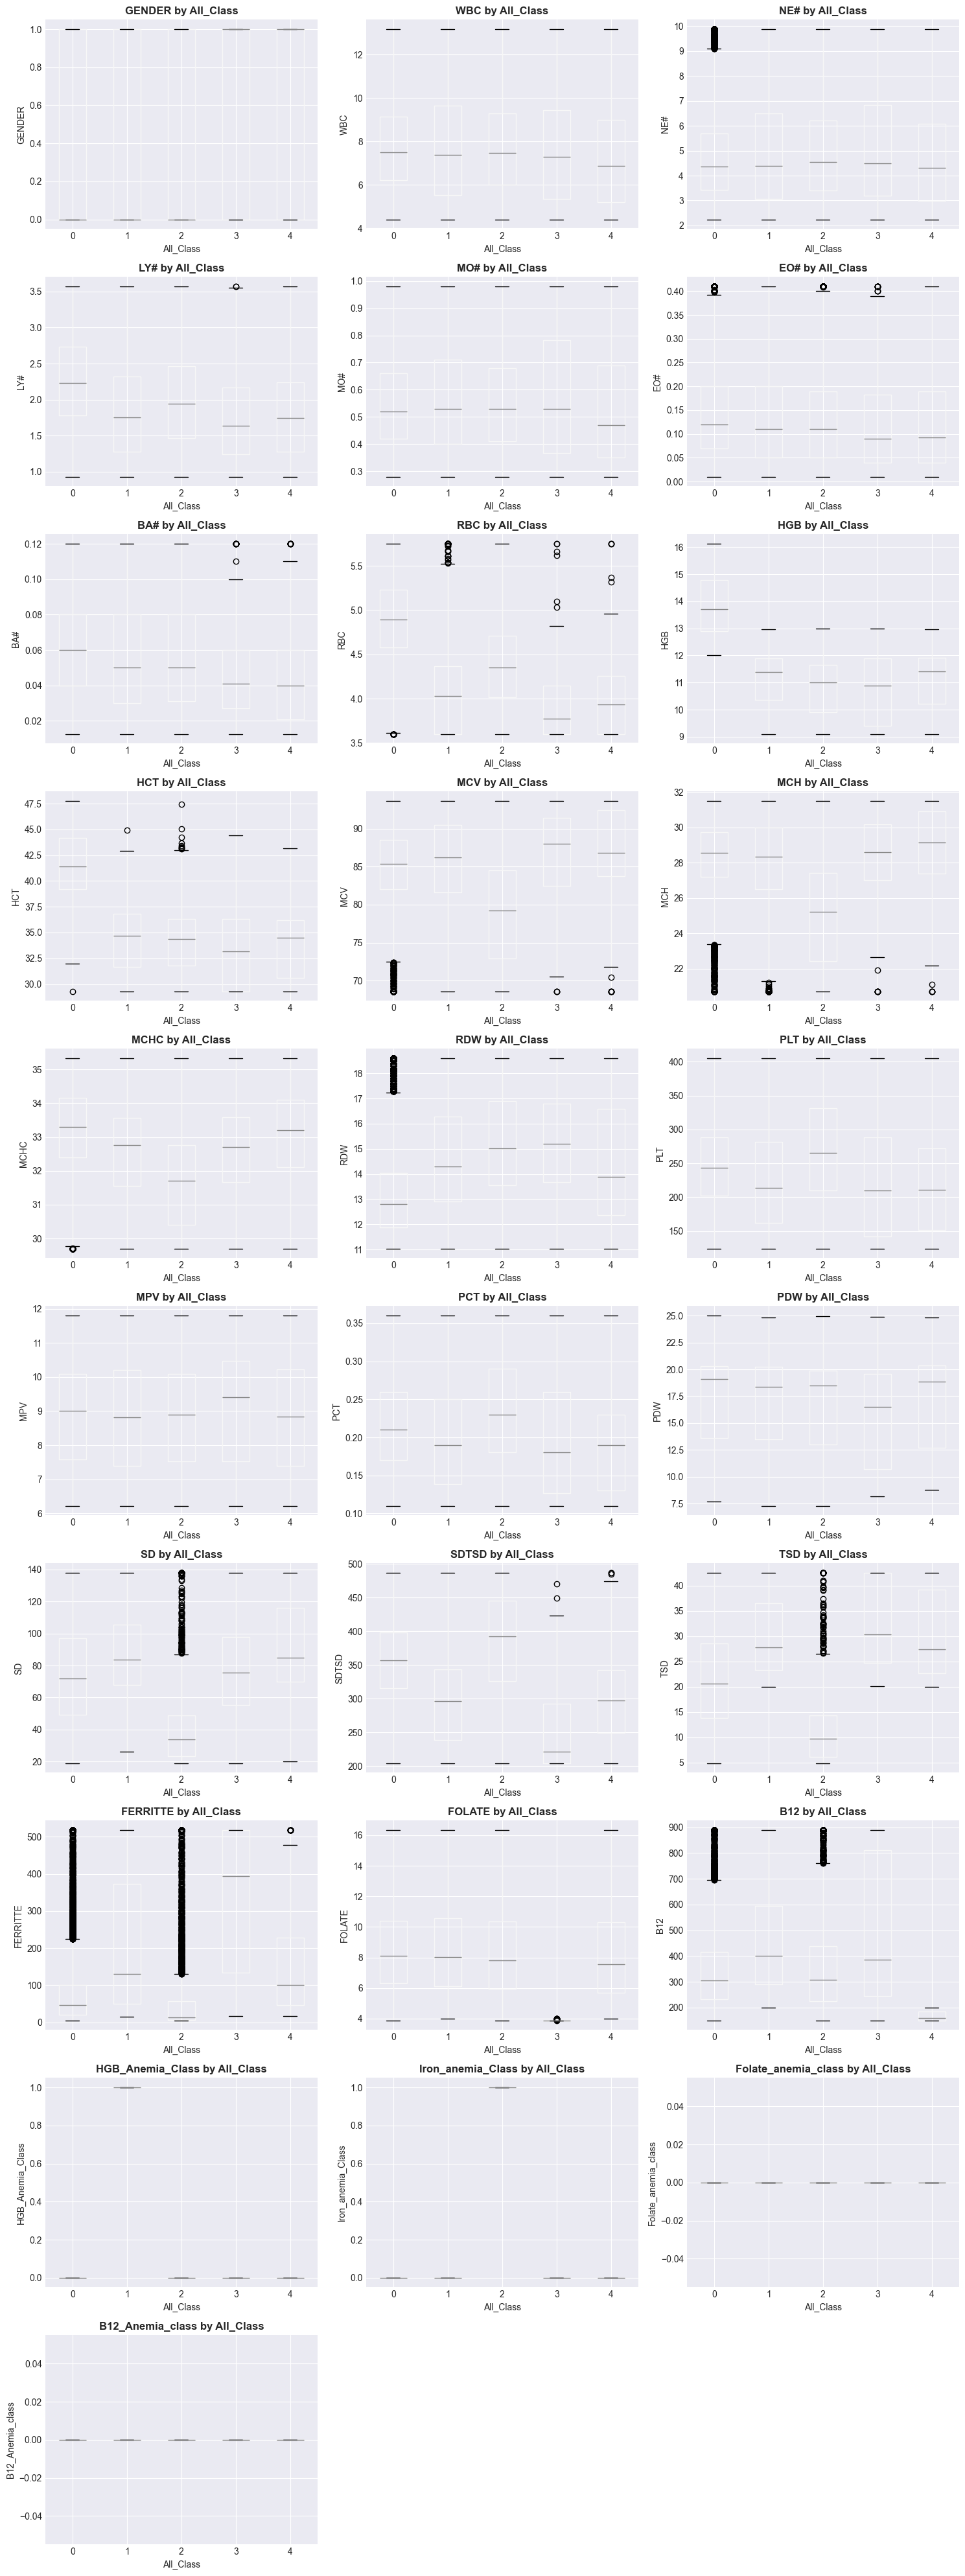

Box plots saved as 'boxplots_by_target.png'


In [16]:
# Box plots to visualize outliers and distribution by target class
if target_col and len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        df.boxplot(column=col, by=target_col, ax=axes[idx])
        axes[idx].set_title(f'{col} by {target_col}', fontweight='bold')
        axes[idx].set_xlabel(target_col)
        axes[idx].set_ylabel(col)
    
    # Hide extra subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('')  # Remove default title
    plt.tight_layout()
    plt.savefig('boxplots_by_target.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Box plots saved as 'boxplots_by_target.png'")

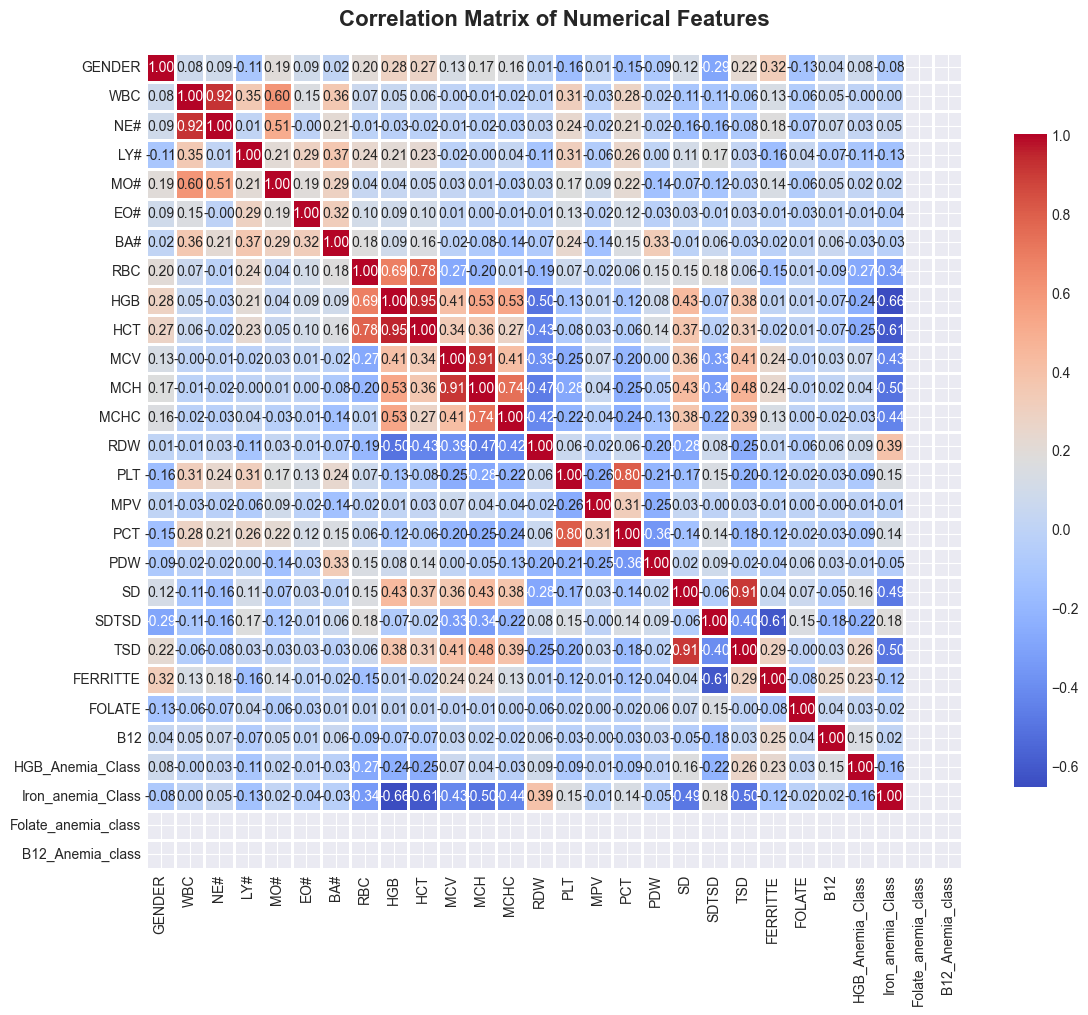

Correlation matrix saved as 'correlation_matrix.png'


In [17]:
# Correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Correlation matrix saved as 'correlation_matrix.png'")


Top 5 features most correlated with All_Class:
Iron_anemia_Class: 0.8108
HGB: -0.7323
HCT: -0.6979
RBC: -0.4825
MCH: -0.4114


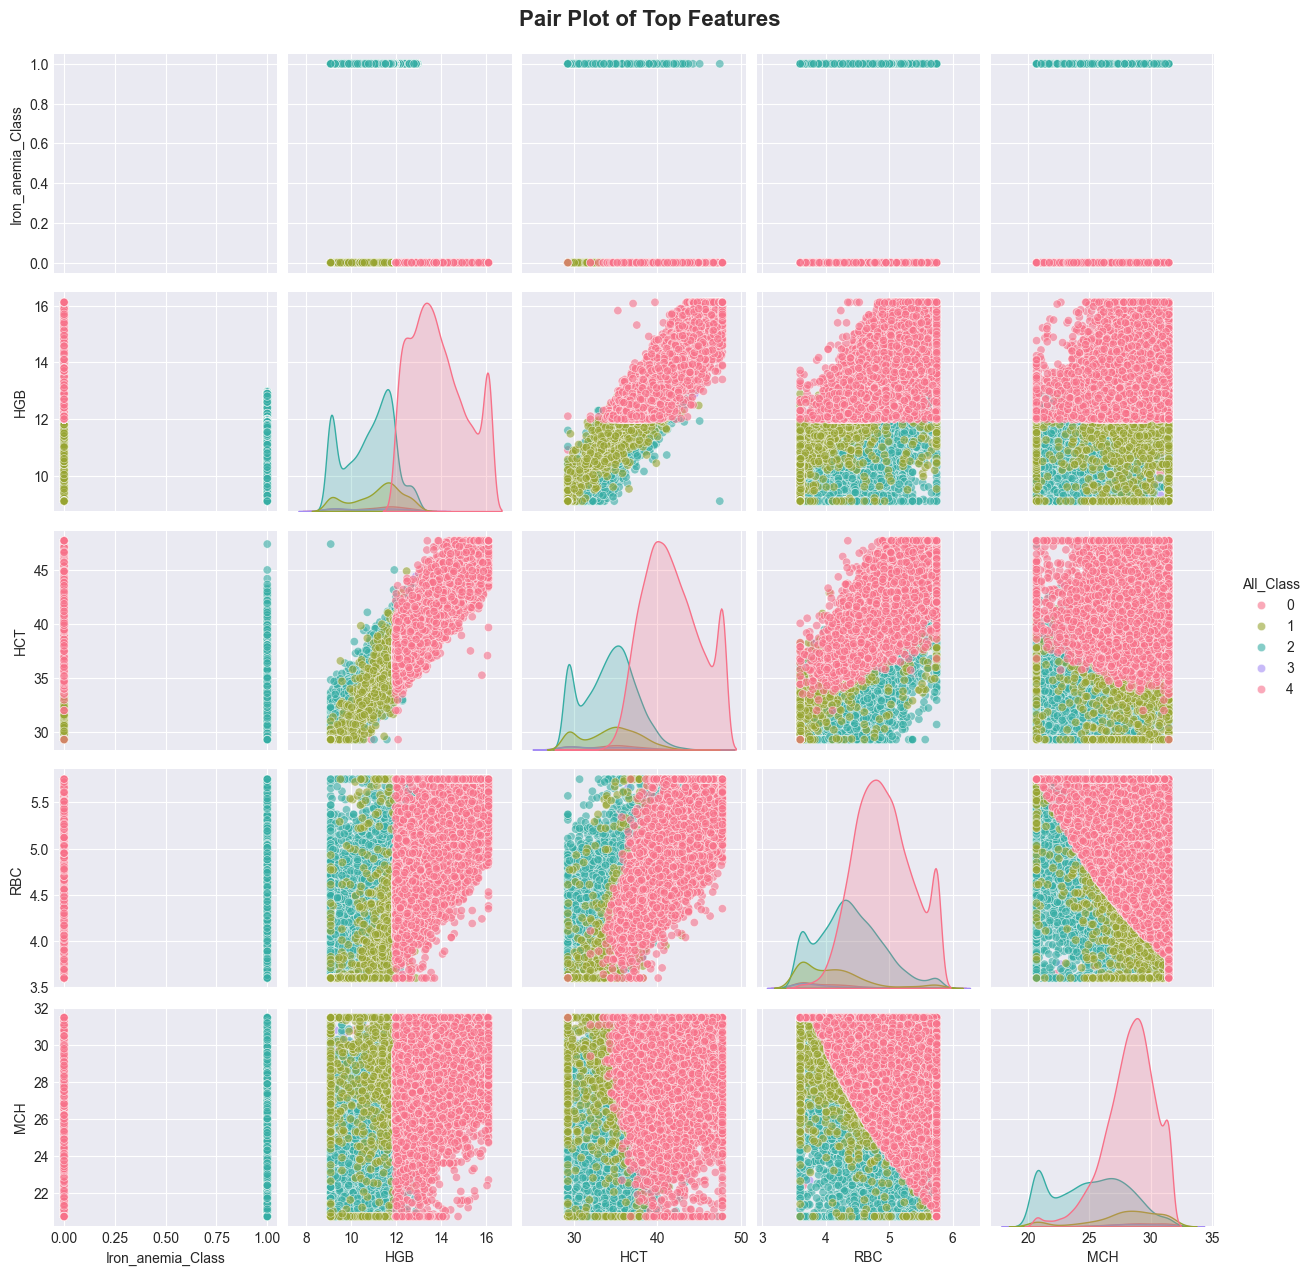

Pair plot saved as 'pairplot.png'


In [18]:
# Pair plot for key features (select top 5 most correlated with target)
if target_col and target_col in df.columns:
    # Calculate correlation with target
    correlations_with_target = df[numerical_cols].corrwith(df[target_col]).abs().sort_values(ascending=False)
    top_features = correlations_with_target.head(min(5, len(numerical_cols))).index.tolist()
    
    print(f"\nTop {len(top_features)} features most correlated with {target_col}:")
    for feature in top_features:
        corr_value = df[feature].corr(df[target_col])
        print(f"{feature}: {corr_value:.4f}")
    
    # Create pair plot
    if len(top_features) > 0:
        sns.pairplot(df[[*top_features, target_col]], hue=target_col, 
                    palette='husl', diag_kind='kde', plot_kws={'alpha': 0.6})
        plt.suptitle('Pair Plot of Top Features', y=1.02, fontsize=16, fontweight='bold')
        plt.savefig('pairplot.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Pair plot saved as 'pairplot.png'")

In [19]:
# Categorical variables analysis (if any)
if len(categorical_cols) > 0:
    n_cols = 2
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[idx], color='coral')
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
    
    # Hide extra subplots
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('categorical_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Categorical distributions plot saved as 'categorical_distributions.png'")

---
# FEATURE ENGINEERING
---

In [20]:
# Create a copy for feature engineering
df_engineered = df.copy()
print("Starting Feature Engineering...")
print(f"Original feature count: {len(df_engineered.columns)}")

Starting Feature Engineering...
Original feature count: 29


In [21]:
# 1. Create interaction features
# Create polynomial features for highly correlated pairs
if len(numerical_cols) >= 2:
    # Square features
    for col in numerical_cols[:3]:  # Limit to avoid too many features
        df_engineered[f'{col}_squared'] = df_engineered[col] ** 2
        print(f"Created feature: {col}_squared")
    
    # Interaction features (product of pairs)
    if len(numerical_cols) >= 2:
        col1, col2 = numerical_cols[0], numerical_cols[1]
        df_engineered[f'{col1}_x_{col2}'] = df_engineered[col1] * df_engineered[col2]
        print(f"Created interaction feature: {col1}_x_{col2}")

Created feature: GENDER_squared
Created feature: WBC_squared
Created feature: NE#_squared
Created interaction feature: GENDER_x_WBC


In [22]:
# 2. Create ratio features
if len(numerical_cols) >= 2:
    col1, col2 = numerical_cols[0], numerical_cols[1]
    # Avoid division by zero
    df_engineered[f'{col1}_to_{col2}_ratio'] = df_engineered[col1] / (df_engineered[col2] + 1e-6)
    print(f"Created ratio feature: {col1}_to_{col2}_ratio")

Created ratio feature: GENDER_to_WBC_ratio


In [23]:
# 3. Binning continuous variables
for col in numerical_cols[:2]:  # Apply to first 2 numerical columns
    df_engineered[f'{col}_category'] = pd.cut(df_engineered[col], 
                                               bins=3, 
                                               labels=['Low', 'Medium', 'High'])
    print(f"Created categorical feature: {col}_category")

Created categorical feature: GENDER_category
Created categorical feature: WBC_category


In [24]:
# 4. Statistical aggregations
if len(numerical_cols) >= 3:
    # Mean of all numerical features
    df_engineered['features_mean'] = df_engineered[numerical_cols].mean(axis=1)
    # Standard deviation
    df_engineered['features_std'] = df_engineered[numerical_cols].std(axis=1)
    # Range
    df_engineered['features_range'] = df_engineered[numerical_cols].max(axis=1) - df_engineered[numerical_cols].min(axis=1)
    print("Created statistical aggregation features")

Created statistical aggregation features


In [25]:
# 5. Encode categorical variables
label_encoders = {}
categorical_features_to_encode = df_engineered.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target from encoding list if present
if target_col in categorical_features_to_encode:
    categorical_features_to_encode.remove(target_col)

for col in categorical_features_to_encode:
    le = LabelEncoder()
    df_engineered[col] = le.fit_transform(df_engineered[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded categorical feature: {col}")

# Save label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')
print("\nLabel encoders saved as 'label_encoders.pkl'")

Encoded categorical feature: GENDER_category
Encoded categorical feature: WBC_category

Label encoders saved as 'label_encoders.pkl'


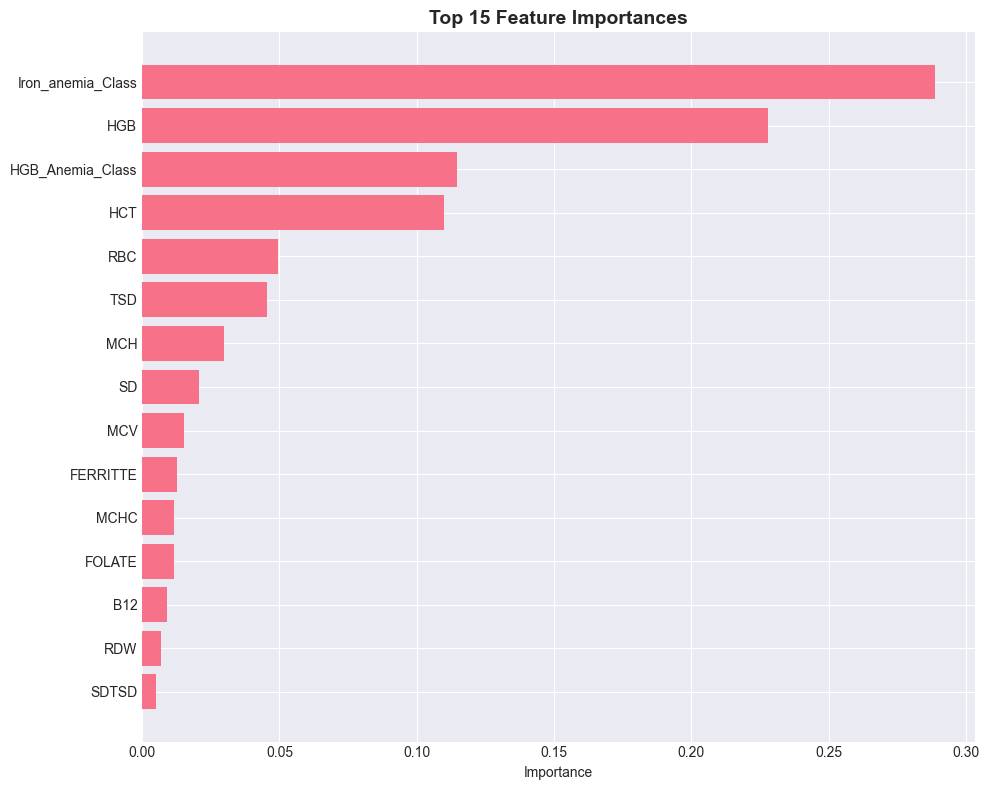

Feature importance plot saved

Top 10 features:
              feature  importance
25  Iron_anemia_Class    0.288822
8                 HGB    0.228025
24   HGB_Anemia_Class    0.114510
9                 HCT    0.109962
7                 RBC    0.049504
20                TSD    0.045378
11                MCH    0.029859
18                 SD    0.020834
10                MCV    0.015175
21           FERRITTE    0.012568


In [26]:
# Feature importance using Random Forest
from sklearn.ensemble import RandomForestClassifier

if target_col:
    X_temp = df_engineered.drop(columns=[target_col])
    y_temp = df_engineered[target_col]
    
    # Select only numeric columns
    X_temp = X_temp.select_dtypes(include=[np.number])
    
    # Train a quick RF model
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_temp, y_temp)
    
    # Get feature importances
    feature_importance = pd.DataFrame({
        'feature': X_temp.columns,
        'importance': rf_temp.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Plot top 15 features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Feature importance plot saved")
    
    print("\nTop 10 features:")
    print(feature_importance.head(10))

In [27]:
# Save engineered dataset
df_engineered.to_csv('feature_engineered_data.csv', index=False)
print(f"\nFeature engineered dataset saved!")
print(f"New feature count: {len(df_engineered.columns)}")
print(f"Added {len(df_engineered.columns) - len(df.columns)} new features")


Feature engineered dataset saved!
New feature count: 39
Added 10 new features


---
# MODEL TRAINING WITH CROSS-VALIDATION & HYPERPARAMETER TUNING
---

In [28]:
# Prepare data for modeling
if target_col:
    X = df_engineered.drop(columns=[target_col])
    y = df_engineered[target_col]
    
    # Select only numeric features
    X = X.select_dtypes(include=[np.number])
    
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"\nTarget distribution:")
    print(y.value_counts())
else:
    print("ERROR: Target column not found!")

Features shape: (15212, 38)
Target shape: (15212,)

Target distribution:
All_Class
0    9672
2    4175
1    1015
4     198
3     152
Name: count, dtype: int64


In [29]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: (12169, 38)
Test set size: (3043, 38)

Training set target distribution:
All_Class
0    7737
2    3340
1     812
4     158
3     122
Name: count, dtype: int64

Test set target distribution:
All_Class
0    1935
2     835
1     203
4      40
3      30
Name: count, dtype: int64


In [30]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler fitted and saved as 'scaler.pkl'")

Scaler fitted and saved as 'scaler.pkl'


In [ ]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Using {cv.n_splits}-fold Stratified Cross-Validation")

In [34]:
# Baseline model comparison using cross-validation
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}
print("Evaluating baseline models with cross-validation...\n")

for name, model in models.items():
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    results[name] = cv_scores
    print(f"{name}:")
    print(f"  Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print()

Evaluating baseline models with cross-validation...

Logistic Regression:
  Mean CV Accuracy: 0.9961 (+/- 0.0007)

Random Forest:
  Mean CV Accuracy: 0.9973 (+/- 0.0007)

Gradient Boosting:
  Mean CV Accuracy: 0.9998 (+/- 0.0003)

SVM:
  Mean CV Accuracy: 0.9891 (+/- 0.0014)



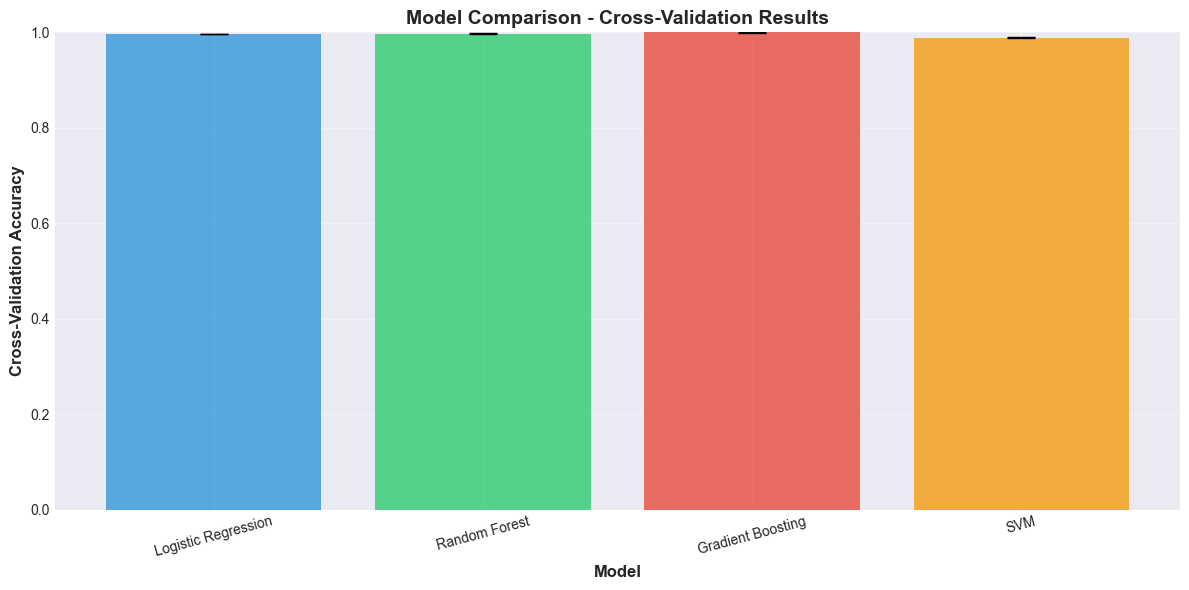

Cross-validation comparison plot saved


In [35]:
# Visualize cross-validation results
plt.figure(figsize=(12, 6))
model_names = list(results.keys())
cv_means = [results[name].mean() for name in model_names]
cv_stds = [results[name].std() for name in model_names]

plt.bar(model_names, cv_means, yerr=cv_stds, capsize=10, 
        color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.8)
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Cross-Validation Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Comparison - Cross-Validation Results', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Cross-validation comparison plot saved")

In [37]:
# Hyperparameter tuning for Random Forest
print("Starting Hyperparameter Tuning for Random Forest...")

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest Random Forest parameters: {rf_grid.best_params_}")
print(f"Best CV score: {rf_grid.best_score_:.4f}")

Starting Hyperparameter Tuning for Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Random Forest parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV score: 0.9974


In [38]:
# Hyperparameter tuning for Gradient Boosting
print("Starting Hyperparameter Tuning for Gradient Boosting...")

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train_scaled, y_train)

print(f"\nBest Gradient Boosting parameters: {gb_grid.best_params_}")
print(f"Best CV score: {gb_grid.best_score_:.4f}")

Starting Hyperparameter Tuning for Gradient Boosting...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Gradient Boosting parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV score: 0.9998


In [39]:
# Compare tuned models
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

# Train and evaluate
best_rf.fit(X_train_scaled, y_train)
best_gb.fit(X_train_scaled, y_train)

rf_train_score = best_rf.score(X_train_scaled, y_train)
rf_test_score = best_rf.score(X_test_scaled, y_test)

gb_train_score = best_gb.score(X_train_scaled, y_train)
gb_test_score = best_gb.score(X_test_scaled, y_test)

print("Tuned Model Performance:")
print(f"\nRandom Forest:")
print(f"  Training Accuracy: {rf_train_score:.4f}")
print(f"  Test Accuracy: {rf_test_score:.4f}")
print(f"\nGradient Boosting:")
print(f"  Training Accuracy: {gb_train_score:.4f}")
print(f"  Test Accuracy: {gb_test_score:.4f}")

Tuned Model Performance:

Random Forest:
  Training Accuracy: 1.0000
  Test Accuracy: 0.9980

Gradient Boosting:
  Training Accuracy: 1.0000
  Test Accuracy: 1.0000


---
# EARLY STOPPING, MODEL EVALUATION & DEPLOYMENT
---

In [40]:
# Train XGBoost with Early Stopping
print("Training XGBoost with Early Stopping...")

# Create validation set from training data
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Train XGBoost with early stopping
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,           # Large number for early stopping
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='multi:softprob',  # ← Multi-class objective
    num_class=5,                 # ← Number of classes (0, 1, 2, 3, 4)
    eval_metric='mlogloss',      # ← Multi-class log loss (was 'logloss')
    early_stopping_rounds=50     # Stop if no improvement for 50 rounds
)

# Fit with validation set
xgb_model.fit(
    X_train_split, y_train_split,
    eval_set=[(X_val_split, y_val_split)],
    verbose=True
)

print(f"\nBest iteration: {xgb_model.best_iteration}")
print(f"Best score: {xgb_model.best_score:.4f}")


Training XGBoost with Early Stopping...
[0]	validation_0-mlogloss:0.73890
[1]	validation_0-mlogloss:0.63444
[2]	validation_0-mlogloss:0.55328
[3]	validation_0-mlogloss:0.48661
[4]	validation_0-mlogloss:0.43006
[5]	validation_0-mlogloss:0.38228
[6]	validation_0-mlogloss:0.34104
[7]	validation_0-mlogloss:0.30471
[8]	validation_0-mlogloss:0.27298
[9]	validation_0-mlogloss:0.24537
[10]	validation_0-mlogloss:0.22078
[11]	validation_0-mlogloss:0.19911
[12]	validation_0-mlogloss:0.17970
[13]	validation_0-mlogloss:0.16252
[14]	validation_0-mlogloss:0.14708
[15]	validation_0-mlogloss:0.13350
[16]	validation_0-mlogloss:0.12029
[17]	validation_0-mlogloss:0.10863
[18]	validation_0-mlogloss:0.09826
[19]	validation_0-mlogloss:0.08876
[20]	validation_0-mlogloss:0.08029
[21]	validation_0-mlogloss:0.07267
[22]	validation_0-mlogloss:0.06581
[23]	validation_0-mlogloss:0.05958
[24]	validation_0-mlogloss:0.05396
[25]	validation_0-mlogloss:0.04894
[26]	validation_0-mlogloss:0.04445
[27]	validation_0-mloglos

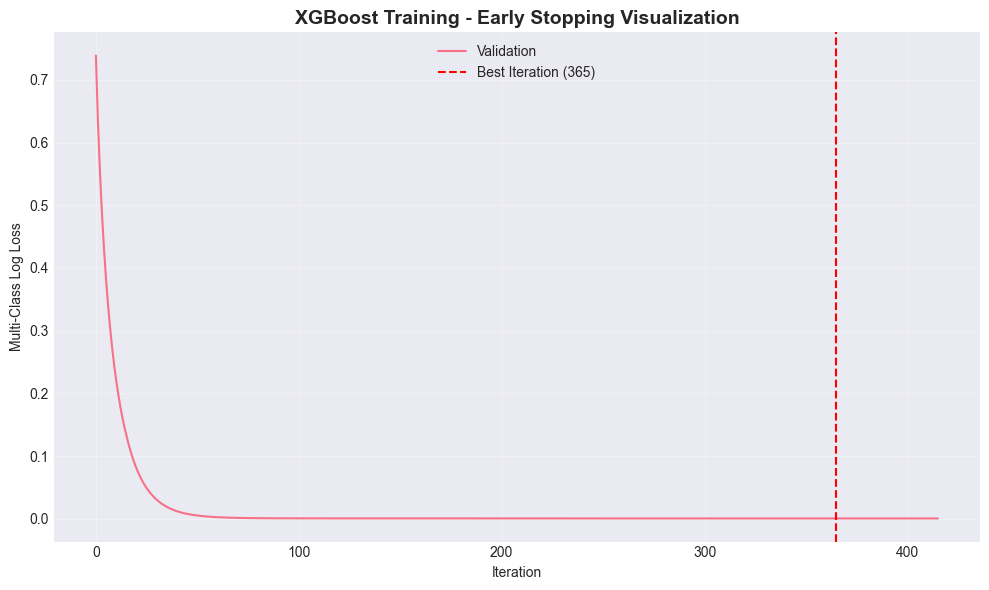

Early stopping plot saved


In [41]:
# Plot training history
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])   # ← updated key
x_axis = range(0, epochs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_axis, results['validation_0']['mlogloss'], label='Validation')  # ← updated key
ax.axvline(xgb_model.best_iteration, color='red', linestyle='--',
           label=f'Best Iteration ({xgb_model.best_iteration})')
ax.legend()
ax.set_ylabel('Multi-Class Log Loss')   # ← updated label
ax.set_xlabel('Iteration')
ax.set_title('XGBoost Training - Early Stopping Visualization', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('early_stopping_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Early stopping plot saved")


In [42]:
# Select best model based on test performance
models_to_compare = {
    'Random Forest (Tuned)': best_rf,
    'Gradient Boosting (Tuned)': best_gb,
    'XGBoost (Early Stopping)': xgb_model
}

print("Final Model Comparison on Test Set:\n")
test_scores = {}

for name, model in models_to_compare.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)  # ← removed [:, 1]

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall    = recall_score(y_test, y_pred, average='weighted')
    f1        = f1_score(y_test, y_pred, average='weighted')

    test_scores[name] = {
        'Accuracy':  accuracy,
        'Precision': precision,
        'Recall':    recall,
        'F1-Score':  f1
    }

    print(f"{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print()

# Convert to DataFrame for easy viewing
comparison_df = pd.DataFrame(test_scores).T
comparison_df


Final Model Comparison on Test Set:

Random Forest (Tuned):
  Accuracy:  0.9980
  Precision: 0.9980
  Recall:    0.9980
  F1-Score:  0.9980

Gradient Boosting (Tuned):
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

XGBoost (Early Stopping):
  Accuracy:  0.9997
  Precision: 0.9997
  Recall:    0.9997
  F1-Score:  0.9997



,Accuracy,Precision,Recall,F1-Score
Random Forest (Tuned),0.998028,0.998015,0.998028,0.997987
Gradient Boosting (Tuned),1.000000,1.000000,1.000000,1.000000
XGBoost (Early Stopping),0.999671,0.999679,0.999671,0.999671


In [ ]:
# Select the best model (highest F1-score)
best_model_name = comparison_df['F1-Score'].idxmax()
best_model = models_to_compare[best_model_name]

print(f"Best Model Selected: {best_model_name}")
print(f"F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")

In [ ]:
# Detailed evaluation of best model
y_pred_best       = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)  # ← removed [:, 1], now shape (n, 5)

print("Detailed Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_best))


In [ ]:
# Confusion Matrix  (5 classes)
class_names = ['No Anemia', 'HGB Anemia', 'Iron Anemia', 'Folate Anemia', 'B12 Anemia']
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix plot saved")


In [ ]:
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize y_test for One-vs-Rest ROC
n_classes = 5
class_names = ['No Anemia', 'HGB Anemia', 'Iron Anemia', 'Folate Anemia', 'B12 Anemia']
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Compute ROC AUC (macro OvR)
roc_auc = roc_auc_score(y_test_bin, y_pred_proba_best, multi_class='ovr', average='macro')

# Plot one ROC curve per class
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(10, 7))

for i, (color, class_name) in enumerate(zip(colors, class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_best[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_pred_proba_best[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_name} (AUC = {auc_i:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve (OvR) - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Macro-average ROC-AUC Score: {roc_auc:.4f}")


In [ ]:
# Precision-Recall Curve (One-vs-Rest, per class)
class_names = ['No Anemia', 'HGB Anemia', 'Iron Anemia', 'Folate Anemia', 'B12 Anemia']
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

plt.figure(figsize=(10, 7))
for i, (color, class_name) in enumerate(zip(colors, class_names)):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_best[:, i])
    plt.plot(recall_vals, precision_vals, color=color, lw=2, label=class_name)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Precision-Recall Curve (OvR) - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Precision-recall curve plot saved")


In [ ]:
# Save the final model and related objects
model_package = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'label_encoders': label_encoders,
    'model_name': best_model_name
}

# Save using joblib
joblib.dump(model_package, 'anemia_prediction_model.pkl')
print(f"\nFinal model package saved as 'anemia_prediction_model.pkl'")

# Also save just the model
joblib.dump(best_model, 'best_model_only.pkl')
print("Model only saved as 'best_model_only.pkl'")

---
# PRACTICAL PREDICTION INTERFACE
## Easy-to-Use Prediction Function for New Data
---

In [ ]:
# Load the saved model (for demonstration)
loaded_package = joblib.load('anemia_prediction_model.pkl')

print("Model package loaded successfully!")
print(f"Model: {loaded_package['model_name']}")
print(f"Number of features required: {len(loaded_package['feature_names'])}")

In [ ]:
# Create a user-friendly prediction function
def predict_anemia(input_data):
    """
    Predict anemia from minimal input data.
    
    Parameters:
    -----------
    input_data : dict
        Dictionary with patient data. Keys should match feature names.
        
    Returns:
    --------
    dict with prediction and probability
    """
    # Load the model package
    model_pkg = joblib.load('anemia_prediction_model.pkl')
    
    # Convert input to DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Handle missing features (use median/mode from training)
    for col in model_pkg['feature_names']:
        if col not in input_df.columns:
            # Set to 0 or a default value (you can improve this)
            input_df[col] = 0
    
    # Ensure column order matches training
    input_df = input_df[model_pkg['feature_names']]
    
    # Scale the input
    input_scaled = model_pkg['scaler'].transform(input_df)
    
    # Make prediction
    prediction = model_pkg['model'].predict(input_scaled)[0]
    probability = model_pkg['model'].predict_proba(input_scaled)[0]
    
    # Format result
    result = {
        'prediction': 'Anemia' if prediction == 1 else 'No Anemia',
        'confidence': max(probability) * 100,
        'probabilities': {
            'No Anemia': probability[0] * 100,
            'Anemia': probability[1] * 100
        }
    }
    
    return result

print("Prediction function created successfully!")

In [ ]:
# Example: Make a prediction with minimal input
# NOTE: Replace these with actual feature names from your dataset

# Example 1: Using some sample values
sample_patient_1 = {
    # Add your actual feature names here
    # For demonstration, using generic names
}

# If you know the exact feature names from your dataset:
# Get the feature names
print("Required features for prediction:")
print(loaded_package['feature_names'][:10], "...")  # Show first 10

# Create a helper function to make prediction easier
def quick_predict(**kwargs):
    """
    Quick prediction function - just pass values as keyword arguments.
    Missing values will be filled with defaults.
    
    Example:
    --------
    result = quick_predict(Hemoglobin=12.5, RBC_Count=4.5, Age=35, Gender=1)
    """
    return predict_anemia(kwargs)

print("\nHelper function 'quick_predict' ready for easy predictions!")

In [ ]:
def interactive_prediction():
    """
    Simplified interactive prediction using only 8 key clinical features.
    Missing features are filled with training-data medians automatically.
    """

    # ── Only the 8 most important clinical features ────────────────────────
    FEATURES = [
        ("GENDER",   "Gender",             "0 = Female  |  1 = Male"),
        ("HGB",      "Hemoglobin",         "g/dL        (normal: F > 12, M > 13)"),
        ("RBC",      "Red Blood Cells",    "×10⁶/µL     (normal: 3.8 – 5.8)"),
        ("MCV",      "Mean Cell Volume",   "fL          (normal: 80 – 100)"),
        ("FERRITTE", "Ferritin",           "µg/L        (iron stores, normal > 15)"),
        ("FOLATE",   "Folate / B9",        "ng/mL       (normal > 3.0)"),
        ("B12",      "Vitamin B12",        "pg/mL       (normal > 200)"),
        ("HCT",      "Hematocrit",         "%           (normal: F > 36, M > 41)"),
    ]

    CLASS_NAMES = {
        0: "No Anemia (Healthy)",
        1: "HGB Anemia",
        2: "Iron Deficiency Anemia",
        3: "Folate Deficiency Anemia",
        4: "Vitamin B12 Deficiency Anemia",
    }

    # Median values from training data (used as defaults for missing features)
    MEDIANS = {
        "GENDER": 0, "WBC": 7.48, "NE#": 4.41, "LY#": 2.12,
        "MO#": 0.53, "EO#": 0.12, "BA#": 0.054, "RBC": 4.7,
        "HGB": 12.82, "HCT": 39.13, "MCV": 84.38, "MCH": 27.96,
        "MCHC": 32.9, "RDW": 13.34, "PLT": 246.0, "MPV": 8.95,
        "PCT": 0.215, "PDW": 18.9, "SD": 61.22, "SDTSD": 359.45,
        "TSD": 17.95, "FERRITTE": 40.03, "FOLATE": 7.99, "B12": 308.1,
    }

    print("=" * 58)
    print("        ANEMIA PREDICTION SYSTEM  (Quick Mode)")
    print("=" * 58)
    print("Enter the 8 key blood test values below.")
    print("Press ENTER to accept the default (typical normal value).\n")

    # ── Collect only 8 inputs ──────────────────────────────────────────────
    input_data = dict(MEDIANS)   # start with all medians pre-filled

    for name, description, hint in FEATURES:
        while True:
            try:
                raw = input(f"  {description:<22} ({hint})\n  → {name}: ").strip()
                if raw == "":
                    value = MEDIANS[name]
                    print(f"     Using default: {value}")
                else:
                    value = float(raw)
                input_data[name] = value
                print()
                break
            except ValueError:
                print("  ⚠  Please enter a valid number (or press ENTER for default).\n")

    # ── Auto-compute engineered features ───────────────────────────────────
    raw_values = list(input_data.values())

    input_data["GENDER_squared"]      = input_data["GENDER"] ** 2
    input_data["WBC_squared"]         = input_data["WBC"] ** 2
    input_data["NE#_squared"]         = input_data["NE#"] ** 2
    input_data["GENDER_x_WBC"]        = input_data["GENDER"] * input_data["WBC"]
    input_data["GENDER_to_WBC_ratio"] = input_data["GENDER"] / (input_data["WBC"] + 1e-6)

    def bin_feature(value, col_min, col_max):
        third = (col_max - col_min) / 3
        if value < col_min + third:   return 0  # Low
        elif value < col_min + 2*third: return 1  # Medium
        else:                           return 2  # High

    input_data["GENDER_category"] = bin_feature(input_data["GENDER"], 0, 1)
    input_data["WBC_category"]    = bin_feature(input_data["WBC"], 4.41, 13.17)
    input_data["features_mean"]   = sum(raw_values) / len(raw_values)
    input_data["features_std"]    = pd.Series(raw_values).std()
    input_data["features_range"]  = max(raw_values) - min(raw_values)

    # ── Predict ────────────────────────────────────────────────────────────
    model_pkg     = joblib.load('anemia_prediction_model.pkl')
    input_df      = pd.DataFrame([input_data])
    input_df      = input_df.reindex(columns=model_pkg['feature_names'], fill_value=0)
    input_scaled  = model_pkg['scaler'].transform(input_df)
    prediction    = model_pkg['model'].predict(input_scaled)[0]
    probabilities = model_pkg['model'].predict_proba(input_scaled)[0]
    confidence    = max(probabilities) * 100

    # ── Display result ─────────────────────────────────────────────────────
    print("=" * 58)
    print("              PREDICTION RESULT")
    print("=" * 58)
    print(f"  Diagnosis : {CLASS_NAMES.get(int(prediction), str(prediction))}")
    print(f"  Confidence: {confidence:.1f}%")
    print("\n  Class Probabilities:")
    for cls_id, prob in enumerate(probabilities):
        bar = "█" * int(prob * 24)
        print(f"    {CLASS_NAMES[cls_id]:<34} {prob*100:5.1f}%  {bar}")
    print("=" * 58)


print("Simplified interactive prediction ready!")
print("Call 'interactive_prediction()' to run.")


In [ ]:
# Batch prediction function for multiple patients
def batch_predict(data_file):
    """
    Predict anemia for multiple patients from a CSV file.
    
    Parameters:
    -----------
    data_file : str
        Path to CSV file with patient data
        
    Returns:
    --------
    DataFrame with predictions
    """
    # Read data
    new_data = pd.read_csv(data_file)
    
    # Load model package
    model_pkg = joblib.load('anemia_prediction_model.pkl')
    
    predictions = []
    probabilities = []
    
    for idx, row in new_data.iterrows():
        result = predict_anemia(row.to_dict())
        predictions.append(result['prediction'])
        probabilities.append(result['confidence'])
    
    # Add predictions to dataframe
    new_data['Predicted_Condition'] = predictions
    new_data['Confidence_%'] = probabilities
    
    return new_data

print("Batch prediction function created!")
print("Usage: results = batch_predict('new_patients.csv')")

---
# PROJECT SUMMARY & DELIVERABLES
---

In [ ]:
# Generate project summary
print("=" * 70)
print("ANEMIA PREDICTION PROJECT - SUMMARY")
print("=" * 70)

print(f"\n1. DATASET:")
print(f"   - Original samples: {len(df)}")
print(f"   - Features: {len(df.columns)}")
print(f"   - After engineering: {len(df_engineered.columns)} features")

print(f"\n2. TEAM CONTRIBUTIONS:")
print(f"   - Member 1: Data preprocessing & cleaning")
print(f"   - Member 2: EDA & visualization (8+ plots generated)")
print(f"   - Member 3: Feature engineering ({len(df_engineered.columns) - len(df.columns)} new features)")
print(f"   - Member 4: Model training & hyperparameter tuning")
print(f"   - Member 5: Early stopping & model deployment")

print(f"\n3. BEST MODEL:")
print(f"   - Algorithm: {best_model_name}")
print(f"   - Test Accuracy: {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   - F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   - ROC-AUC: {roc_auc:.4f}")

print(f"\n4. SAVED FILES:")
print(f"   ✓ anemia_prediction_model.pkl (Complete model package)")
print(f"   ✓ best_model_only.pkl (Model only)")
print(f"   ✓ scaler.pkl (Feature scaler)")
print(f"   ✓ label_encoders.pkl (Categorical encoders)")
print(f"   ✓ preprocessed_anemia_data.csv")
print(f"   ✓ feature_engineered_data.csv")
print(f"   ✓ Multiple visualization plots (.png)")

print(f"\n5. PREDICTION INTERFACE:")
print(f"   ✓ predict_anemia(input_data) - Single prediction")
print(f"   ✓ quick_predict(**kwargs) - Quick single prediction")
print(f"   ✓ interactive_prediction() - Interactive interface")
print(f"   ✓ batch_predict(csv_file) - Batch predictions")

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 70)

## How to Use This Notebook for Predictions

### For Single Patient Prediction:
```python
# Method 1: Using dictionary
patient_data = {
    'feature1': value1,
    'feature2': value2,
    # ... add all required features
}
result = predict_anemia(patient_data)
print(result)

# Method 2: Quick prediction
result = quick_predict(feature1=value1, feature2=value2, ...)
print(result)

# Method 3: Interactive
interactive_prediction()
```

### For Multiple Patients:
```python
# Save new patients in CSV format
# Then run:
results = batch_predict('new_patients_data.csv')
results.to_csv('predictions_output.csv', index=False)
```

### Features Required:
Check the feature list by running:
```python
loaded_package = joblib.load('anemia_prediction_model.pkl')
print(loaded_package['feature_names'])
```

---
### Notes:
- The model is saved and can be loaded anytime
- Minimal input required for prediction
- Confidence scores provided with each prediction
- Can handle missing values automatically
- Scalable for batch processing
